<a href="https://colab.research.google.com/github/andluizsouza/unicamp-llm-agents/blob/main/modules/01_fundamentos_ia_pln/hands_on_final_test_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Avaliativa**  
## **Instituto de Computação**  
## **Universidade Estadual de Campinas \- UNICAMP**  
### **Curso**: INF0087 - Sistemas Inteligentes com Agentes Autônomos usando Grandes Modelos de Linguagem
### **Disciplina**: Fundamentos de IA Generativa e PLN
### **Professor**: Prof. Dr. Rodrigo Bonacin

### **Aluno**: Anderson Luiz Brandão de Souza
### **Data**: 11 de maio de 2026

***

#### **1. Descrição da Atividade:**

* Realizar o ajuste fino:
  * Usar um LLM pequeno como base, ex.: TinyLlama/TinyLlama-1.1B-Chat-v1.0, google/gemma-3-1b-pt …  
  * Para fazer o fine-tuning supervisionado, utilizar o dataset “HuggingFaceTB/smoltalk2”, subconjunto/subset “SFT” e Split “sft\_smoltalk\_multilingual\_8languages\_lang\_5\_no\_think” (link: [https://huggingface.co/datasets/HuggingFaceTB/smoltalk2/viewer/SFT/smoltalk\_multilingual\_8languages\_lang\_5\_no\_think](https://huggingface.co/datasets/HuggingFaceTB/smoltalk2/viewer/SFT/smoltalk_multilingual_8languages_lang_5_no_think)). Dica: baixe o dataset no seu gdrive (ou local) para não precisar baixá-lo a cada execução.   
  * Aplicar QLoRA para realizar o ajuste fino de instruções.  
  * Ilustrar, com exemplos, as diferenças de geração entre o modelo de base e o ajustado.

<br>

#### **2. Critérios de Avaliação:**  
Os seguintes critérios serão considerados com igual peso (25% cada):

* Complexidade:   
  * Por ser uma atividade aberta, pode ser executada em diferentes níveis de complexidade. Por exemplo: um ajuste mais refinado dos parâmetros do QLoRA, uma análise comparativa dos modelos ou a filtragem dos dados de treinamento acrescentam nota, mas não são essenciais.     
* Completude:  
  * A atividade completa inclui carregar a LLM de base, carregar o conjunto de dados para o SFT, realizar o ajuste fino com QLoRA e verificar as diferenças nas respostas. O ajuste por preferências não faz parte da avaliação (não vale nota) e é uma atividade extra para os alunos que desejarem testar suas habilidades.    
* Corretude:  
  * Ausência de bugs, código eficiente e uso adequado da linguagem Python e bibliotecas.   
* Documentação:  
  * Os códigos deverão ser acompanhados de documentação que explique cada passo no notebook, ou seja, intercalando blocos de texto e de código. A documentação mais completa e clara receberá uma nota maior.

Importante: não fazem parte da avaliação aspectos que dependem apenas do poder computacional disponível (ex.: um conjunto de treinamento muito grande não influencia a nota).

<br>

#### **3. Modo de Entrega:**

**A atividade é Individual.**
Os alunos deverão copiar este notebook, incluir documentação (blocos de texto) e códigos, abaixo deste enunciado e também, as saídas de cada bloco de código.    

A entrega do notebook (.ipynb) será feita por meio da atividade no Google ClassRoom.  


---

# **Resolução da Atividade Avaliativa**

## Visão Geral

Nesta atividade, realizaremos o **ajuste fino supervisionado (SFT)** do modelo **Google Gemma 3 1B** (versão pré-treinada) utilizando a técnica **QLoRA** (Quantized Low-Rank Adaptation), treinando-o com dados instrucionais em **português** extraídos do dataset SmolTalk2.

### Decisões de Arquitetura

| Aspecto | Escolha | Justificativa |
|---------|---------|---------------|
| **Modelo base** | `google/gemma-3-1b-pt` | Modelo pré-treinado (decoder-only, autorregressivo) com 1B de parâmetros. Tamanho adequado para o Colab gratuito (T4 16GB). |
| **Tokenizer** | `google/gemma-3-1b-it` | A versão instruction-tuned contém o `chat_template` necessário para formatar exemplos de SFT no formato de diálogo. |
| **Quantização** | QLoRA 4-bit (NF4) | Redução de ~8x em memória. O formato NormalFloat4 é otimizado para a distribuição de pesos de LLMs, baseado em blocos de quantização com distribuição normal. |
| **Dataset** | SmolTalk2 (SFT, multilingual) | Dataset instrucional multilíngue com 254k exemplos em 8 idiomas. |
| **Filtragem** | Pipeline de qualidade (8 etapas) | Filtro PT-BR + limpeza de texto + remoção de evasivas + deduplicação + validação de papéis + filtragem de comprimento → 3.000 amostras de alta qualidade. |
| **LoRA rank** | r=16 | Equilíbrio entre capacidade de adaptação e eficiência. Ranks 8-32 são recomendados para modelos de 1B+ parâmetros. |

### Pipeline de Execução

```
Fase 1: Config      → Instalar dependências, verificar GPU
Fase 2: Dados       → Carregar, filtrar (pipeline de qualidade), amostrar 3.000
Fase 3: Modelo      → Carregar com quantização 4-bit, gerar baseline
Fase 4: Treino      → SFT com QLoRA via SFTTrainer
Fase 5: Avaliação   → Comparação qualitativa: modelo base vs ajustado
Fase 6: Extra       → Ajuste por preferências (DPO)
```

---

## Fase 1: Configuração do Ambiente

### Step 1 — Instalação de Dependências e Verificação do Ambiente

Instalamos as bibliotecas essenciais para o pipeline de fine-tuning:

- **`transformers`**: Modelos e tokenizers da Hugging Face
- **`datasets`**: Carregamento e manipulação de datasets
- **`peft`**: Parameter-Efficient Fine-Tuning (LoRA/QLoRA)
- **`trl`**: Trainers especializados para LLMs (`SFTTrainer`, `DPOTrainer`)
- **`bitsandbytes`**: Quantização 4-bit para QLoRA
- **`accelerate`**: Otimização de treinamento distribuído em GPU
- **`langdetect`**: Detecção de idioma para validação da filtragem por português

In [1]:
!pip install -q transformers datasets peft trl bitsandbytes accelerate huggingface_hub langdetect matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.8 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
import glob
import logging

import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
from tqdm import tqdm

from datasets import load_dataset, load_from_disk, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig

In [3]:
# Verificar GPU disponível
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print("GPU detectada:")
    print(result.stdout)
else:
    print("Nenhuma GPU detectada.")
    print("⚠️ GPU não disponível! Este notebook requer GPU para treinamento.")

GPU detectada:
Mon May 11 23:14:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------------

In [5]:
# ── Login no HuggingFace (necessário para acessar o Gemma) ──
# No Google Colab, configure o token via Secrets:
#   Menu lateral → 🔑 Secrets → Adicionar "HF_TOKEN_READ" com seu token
# Esse token deve ter permissão de READ

from huggingface_hub import login

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN_READ")
    login(token=HF_TOKEN)
    print("✅ Login via Colab Secrets")
except ValueError:
  logging.error("Falha na autenticação com HuggingFace")

✅ Login via Colab Secrets


---

## Fase 2: Exploração e Preparação dos Dados

In [7]:
# ── Carregar dataset em modo streaming ──
## Análise prévia: dados brutos do dataset de SFT

ds_stream = load_dataset(
    "HuggingFaceTB/smoltalk2",
    "SFT",
    split="smoltalk_multilingual_8languages_lang_5_no_think",
    streaming=True,
)

n_examples = 5

# Inspecionar schema e primeiros exemplos
first_examples = list(islice(ds_stream, n_examples))

print("=== Colunas disponíveis ===")
print(list(first_examples[0].keys()))

for idx, ex in enumerate(first_examples):
    print(f"\n{'='*60}")
    print(f"Exemplo {idx + 1} / {n_examples}")
    print(f"{'='*60}")
    for msg in ex["messages"]:
        preview = msg["content"][:150]
        ellipsis = "..." if len(msg["content"]) > 150 else ""
        print(f"  [{msg['role']}]: {preview}{ellipsis}")
    if "chat_template_kwargs" in ex:
        print(f"  [chat_template_kwargs]: {ex['chat_template_kwargs']}")

Resolving data files:   0%|          | 0/124 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

=== Colunas disponíveis ===
['messages', 'chat_template_kwargs', 'source']

Exemplo 1 / 5
  [user]: O diretor da escola, juntamente com os professores e demais funcionários, ficou muito satisfeito ao concluir com sucesso a difícil tarefa de organizar...
  [assistant]: O diretor da escola, em conjunto com os professores e demais funcionários, sentiu-se extremamente satisfeito ao concluir com êxito a árdua tarefa de o...
  [chat_template_kwargs]: {'custom_instructions': '', 'enable_thinking': False, 'python_tools': [], 'xml_tools': []}

Exemplo 2 / 5
  [user]: J'aimerais commencer le vélotourisme.
  [assistant]: Le vélotourisme est une excellente façon de découvrir de nouveaux paysages, de vivre des aventures et de se maintenir en forme. Pour bien commencer, i...
  [chat_template_kwargs]: {'custom_instructions': '', 'enable_thinking': False, 'python_tools': [], 'xml_tools': []}

Exemplo 3 / 5
  [user]: ¿Cuáles son algunos síntomas comunes de un resfriado y cuánto tiempo suelen durar? Tu 

### Step 2 — Pipeline de Filtragem e Qualidade do Dataset SmolTalk2

O dataset **[SmolTalk2](https://huggingface.co/datasets/HuggingFaceTB/smoltalk2)** contém três subconjuntos usados no pós-treinamento do SmolLM3-3B:
- **Mid**: Dados para mid-training (4.8M rows)
- **SFT**: Dados para Supervised Fine-Tuning (3.4M rows, 25 splits)
- **Preference**: Dados para alinhamento por preferências (447k rows)

Utilizaremos o split **`smoltalk_multilingual_8languages_lang_5_no_think`** do subconjunto SFT.

A eficácia e eficiência do SFT depende fortemente da quantidade e qualidade dos dados. Para qualidade, foi desenvolvido um pipeline de filtragem e remoção de possíveis dados não-conforme. O objetivo final é gerar um dataset mais curado para a etapa de SFT.

**Pipeline de filtragem e qualidade (8 etapas):**

| Etapa | Ação | Importância |
|-------|------|-------------|
| **1. Carregamento** | Carregar do dataset via streaming | Ponto de partida dos dados |
| **2. Filtro de idioma** | `langdetect` na primeira mensagem do usuário | Garantir que **apenas exemplos em português** passem para o treino |
| **3. Limpeza de texto** | Regex para espaços extras, quebras redundantes, caracteres de controle | Modelo aprende gramática limpa para gerar respostas fluidas |
| **4. Validação de papéis** | Verificar presença de turnos `user` e `assistant` | Garantir estrutura compatível com o chat template do Gemma 3 |
| **5. Filtro de evasivas** | Remover respostas genéricas ("Como um modelo de IA...") | Ensinar o modelo a responder de forma direta e informativa |
| **6. Comprimento mínimo** | Remover respostas do assistente com <10 caracteres | Respostas curtas não contribuem para fluidez ou raciocínio |
| **7. Erros de encoding** | Detectar UTF-8 mal decodificado, caracteres corrompidos | Evitar que o modelo aprenda artefatos de codificação |
| **8. Deduplicação** | Hash MD5 estrutural por conteúdo das mensagens | Aumentar diversidade, evitar memorização de padrões |

Ao final, o dataset é **embaralhado** e limitado a **3.000 amostras** de alta qualidade — volume ideal para SFT em modelos leves como o Gemma 3 1B em ambientes de recursos limitados (Colab T4).

In [8]:
import re
import random
import hashlib
from langdetect import detect, DetectorFactory, LangDetectException

# Semente para reprodutibilidade na detecção de idioma
DetectorFactory.seed = 42

# ═══════════════════════════════════════════════════════════════════════
# FUNÇÕES DE FILTRAGEM E QUALIDADE PARA SFT
# ═══════════════════════════════════════════════════════════════════════


def load_subset(max_scan: int = 80_000) -> list:
    """
    Carrega exemplos do split lang_5 do SmolTalk2 via streaming.
    """
    ds_stream = load_dataset(
        "HuggingFaceTB/smoltalk2",
        "SFT",
        split="smoltalk_multilingual_8languages_lang_5_no_think",
        streaming=True,
    )

    examples = []
    for example in tqdm(ds_stream, desc="Carregando exemplos", total=max_scan):
        examples.append(example)
        if len(examples) >= max_scan:
            break
    return examples


# ── Filtro de Idioma ──

def detect_language(messages: list) -> str:
    """Detecta o idioma a partir da primeira mensagem do usuário."""
    for msg in messages:
        if msg["role"] == "user":
            try:
                return detect(msg["content"])
            except LangDetectException:
                return "unknown"
    return "unknown"


def filter_portuguese(examples: list) -> tuple[list, dict]:
    """
    Filtra exemplos em português usando langdetect.

    Returns:
        Tupla (exemplos_pt, contagem_por_idioma).
    """
    pt_examples = []
    lang_counts = {}

    for ex in tqdm(examples, desc="Detectando idioma"):
        lang = detect_language(ex["messages"])
        lang_counts[lang] = lang_counts.get(lang, 0) + 1
        if lang == "pt":
            pt_examples.append(ex)

    return pt_examples, lang_counts


# ── Limpeza e Normalização de Texto ──

def clean_text(text: str) -> str:
    """
    Normaliza formatação: espaços extras, quebras de linha redundantes
    e caracteres de controle.
    """
    text = re.sub(r'\n{3,}', '\n\n', text)                          # Quebras redundantes
    text = re.sub(r'[ \t]{2,}', ' ', text)                          # Espaços múltiplos
    text = re.sub(r'(?m)^[ \t]+|[ \t]+$', '', text)                 # Espaços em bordas de linha
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)   # Caracteres de controle
    return text.strip()


def clean_messages(example: dict) -> dict:
    """Aplica limpeza de texto em todas as mensagens de um exemplo."""
    example["messages"] = [
        {**msg, "content": clean_text(msg["content"])}
        for msg in example["messages"]
    ]
    return example


# ── Filtro de Respostas Evasivas (padrão Zephyr) ──

EVASIVE_PATTERNS = [
    r'como\s+(um|uma)\s+(modelo|ia|inteligência\s+artificial|assistente)',
    r'não\s+tenho\s+(opiniões|sentimentos|emoções|preferências)',
    r'não\s+sinto\s+(emoções|sentimentos)',
    r'não\s+posso\s+(ter|expressar)\s+(opiniões|sentimentos)',
    r'sou\s+apenas\s+(um|uma)\s+(modelo|programa|ia)',
    r'as\s+an?\s+ai\s+(model|language|assistant)',
    r"i\s+don'?t\s+have\s+(opinions|feelings|emotions)",
    r'i\s+am\s+(just|only)\s+an?\s+(ai|language|model)',
    r'não\s+me\s+é\s+possível\s+(opinar|julgar|sentir)',
    r'não\s+cabe\s+a\s+mim\s+(opinar|julgar)',
]

_EVASIVE_COMPILED = [re.compile(p, re.IGNORECASE) for p in EVASIVE_PATTERNS]


def is_evasive_response(text: str) -> bool:
    """Detecta respostas evasivas/genéricas (padrão Zephyr/hedging)."""
    return any(pat.search(text) for pat in _EVASIVE_COMPILED)


def filter_evasive(example: dict) -> bool:
    """Retorna True se o exemplo NÃO contém respostas evasivas."""
    for msg in example["messages"]:
        if msg["role"] == "assistant" and is_evasive_response(msg["content"]):
            return False
    return True


# ── Validação de Papéis de Chat ──

def validate_chat_roles(example: dict) -> bool:
    """Valida que o exemplo contém pelo menos um turno de user e um de assistant."""
    roles = {msg["role"] for msg in example["messages"]}
    return "user" in roles and "assistant" in roles


# ── Filtragem por Comprimento Mínimo ──

def filter_min_length(example: dict, min_chars: int = 10) -> bool:
    """Remove exemplos com respostas do assistente muito curtas."""
    for msg in example["messages"]:
        if msg["role"] == "assistant" and len(msg["content"].strip()) < min_chars:
            return False
    return True


# ── Detecção de Erros de Codificação ──

ENCODING_ERROR_PATTERNS = [
    re.compile(r'Ã[£¡â©ª³º]'),          # UTF-8 mal decodificado
    re.compile(r'â€[™""]'),              # Aspas/apóstrofos corrompidos
    re.compile(r'Â[\xa0]'),              # Non-breaking space corrompido
    re.compile(r'\ufffd'),                # Caractere de substituição Unicode
    re.compile(r'\\u[0-9a-fA-F]{4}'),    # Escapes Unicode não resolvidos
]


def has_encoding_errors(text: str) -> bool:
    """Detecta erros óbvios de codificação de texto."""
    return any(pat.search(text) for pat in ENCODING_ERROR_PATTERNS)


def filter_encoding_errors(example: dict) -> bool:
    """Retorna True se o exemplo NÃO contém erros de codificação."""
    for msg in example["messages"]:
        if has_encoding_errors(msg["content"]):
            return False
    return True


# ── Deduplicação Estrutural ──

def compute_message_hash(example: dict) -> str:
    """Computa hash MD5 estrutural baseado no conteúdo das mensagens."""
    content = "|".join(
        f"{msg['role']}:{msg['content'].strip().lower()}"
        for msg in example["messages"]
    )
    return hashlib.md5(content.encode()).hexdigest()


def deduplicate(examples: list) -> list:
    """Remove duplicatas estruturais baseadas no hash das mensagens."""
    seen = set()
    unique = []
    for ex in examples:
        h = compute_message_hash(ex)
        if h not in seen:
            seen.add(h)
            unique.append(ex)
    return unique


# ═══════════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ═══════════════════════════════════════════════════════════════════════

def prepare_sft_dataset(
    max_scan: int = 80_000,
    target_samples: int = 3_000,
    min_response_chars: int = 10,
    save_path: str = "./data/smoltalk2_pt_filtered",
    seed: int = 42,
) -> Dataset:
    """
    Pipeline completo de preparação do dataset para SFT.

    Etapas:
      1. Carregar split lang_5 via streaming
      2. Filtrar por idioma português (langdetect)
      3. Limpeza e normalização de texto
      4. Validação de papéis de chat (user/assistant)
      5. Remoção de respostas evasivas (padrão Zephyr)
      6. Filtragem de comprimento mínimo
      7. Remoção de erros de codificação
      8. Deduplicação estrutural
      9. Embaralhar e selecionar as melhores amostras
smoltalk-multilingual-8languages_lang_5_no_think
    Returns:
        Dataset pronto para SFT com até `target_samples` amostras.
    """
    # Verificar cache local
    if os.path.exists(save_path):
        dataset = load_from_disk(save_path)
        print(f"✅ Dataset carregado do cache local: {save_path}")
        print(f"   Amostras: {len(dataset)}")
        return dataset

    stats = {}

    print("=" * 60)
    print("  PIPELINE DE FILTRAGEM E QUALIDADE PARA SFT")
    print("=" * 60)

    # 1. Carregar dados do split lang_5
    examples = load_subset(max_scan)
    stats["01_carregados"] = len(examples)
    print(f"\n[1/8] Exemplos carregados (split lang_5):  {len(examples):,}")

    # 2. Filtrar por idioma português
    before = len(examples)
    examples, lang_counts = filter_portuguese(examples)
    stats["02_nao_portugues"] = before - len(examples)
    print(f"[2/8] Filtro de idioma (português):        {len(examples):,}  (removidos: {before - len(examples)})")
    print(f"      Distribuição de idiomas detectados:")
    for lang, count in sorted(lang_counts.items(), key=lambda x: -x[1])[:8]:
        pct = 100 * count / before
        marker = " ← selecionado" if lang == "pt" else ""
        print(f"        {lang}: {count:,} ({pct:.1f}%){marker}")

    # 3. Limpeza de texto
    before = len(examples)
    examples = [clean_messages(ex) for ex in examples]
    stats["03_limpeza_dados"] = before - len(examples)
    print(f"[3/8] Limpeza de texto aplicada:           {len(examples):,}  (removidos: {before - len(examples)})")

    # 4. Validação de papéis de chat
    before = len(examples)
    examples = [ex for ex in examples if validate_chat_roles(ex)]
    stats["04_roles_removidos"] = before - len(examples)
    print(f"[4/8] Validação de papéis:                 {len(examples):,}  (removidos: {before - len(examples)})")

    # 5. Remoção de respostas evasivas
    before = len(examples)
    examples = [ex for ex in examples if filter_evasive(ex)]
    stats["05_evasivas_removidas"] = before - len(examples)
    print(f"[5/8] Filtro de evasivas (Zephyr):         {len(examples):,}  (removidas: {before - len(examples)})")

    # 6. Filtragem de comprimento mínimo
    before = len(examples)
    examples = [ex for ex in examples if filter_min_length(ex, min_response_chars)]
    stats["06_curtas_removidas"] = before - len(examples)
    print(f"[6/8] Filtro de comprimento (>={min_response_chars} chars):  {len(examples):,}  (removidas: {before - len(examples)})")

    # 7. Erros de codificação
    before = len(examples)
    examples = [ex for ex in examples if filter_encoding_errors(ex)]
    stats["07_encoding_removidos"] = before - len(examples)
    print(f"[7/8] Filtro de encoding:                  {len(examples):,}  (removidos: {before - len(examples)})")

    # 8. Deduplicação estrutural
    before = len(examples)
    examples = deduplicate(examples)
    stats["08_duplicatas_removidas"] = before - len(examples)
    print(f"[8/8] Deduplicação:                        {len(examples):,}  (duplicatas: {before - len(examples)})")

    # 9. Embaralhar e amostrar
    random.seed(seed)
    random.shuffle(examples)

    if len(examples) > target_samples:
        examples = examples[:target_samples]

    stats["09_final"] = len(examples)

    # Converter para Dataset e salvar
    dataset = Dataset.from_list(examples)
    dataset.save_to_disk(save_path)

    print(f"\n{'=' * 60}")
    print(f"  RESUMO DO PIPELINE")
    print(f"{'=' * 60}")
    for key, value in stats.items():
        step_name = key.split("_", 1)[1].replace("_", " ").capitalize()
        print(f"  {key}: {value:>6,}  ({step_name})")
    print(f"\n  ✅ Dataset final: {len(dataset):,} amostras")
    print(f"  📁 Salvo em: {save_path}")

    return dataset


print("✅ Funções de filtragem e qualidade definidas.")

✅ Funções de filtragem e qualidade definidas.


In [9]:
# ── Executar pipeline de filtragem e qualidade ──
dataset_pt = prepare_sft_dataset(
    max_scan=80_000,           # Máximo de exemplos a escanear do streaming
    target_samples=3_000,      # Amostras finais para SFT
    min_response_chars=10,     # Comprimento mínimo de respostas do assistente
    save_path="./data/smoltalk2_pt_filtered",
    seed=42,
)

# ── Exibir exemplos do dataset filtrado ──
N_PREVIEW = 5
print(f"\n{'=' * 60}")
print(f"  AMOSTRA DO DATASET FILTRADO ({N_PREVIEW} exemplos)")
print(f"{'=' * 60}")

for idx in range(N_PREVIEW):
    print(f"\n--- Exemplo {idx + 1} ---")
    for msg in dataset_pt[idx]["messages"]:
        preview = msg["content"][:200]
        ellipsis = "..." if len(msg["content"]) > 200 else ""
        print(f"  [{msg['role']}]: {preview}{ellipsis}")
    print()

  PIPELINE DE FILTRAGEM E QUALIDADE PARA SFT


Resolving data files:   0%|          | 0/124 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/113 [00:00<?, ?it/s]

Carregando exemplos: 100%|█████████▉| 79999/80000 [00:24<00:00, 3212.42it/s]



[1/8] Exemplos carregados (split lang_5):  80,000


Detectando idioma: 100%|██████████| 80000/80000 [04:05<00:00, 325.70it/s]


[2/8] Filtro de idioma (português):        15,657  (removidos: 64343)
      Distribuição de idiomas detectados:
        de: 16,560 (20.7%)
        fr: 16,045 (20.1%)
        es: 16,037 (20.0%)
        pt: 15,657 (19.6%) ← selecionado
        it: 15,241 (19.1%)
        en: 302 (0.4%)
        ca: 98 (0.1%)
        nl: 12 (0.0%)
[3/8] Limpeza de texto aplicada:           15,657
[4/8] Validação de papéis:                 15,657  (removidos: 0)
[5/8] Filtro de evasivas (Zephyr):         15,639  (removidas: 18)
[6/8] Filtro de comprimento (>=10 chars):  15,635  (removidas: 4)
[7/8] Filtro de encoding:                  15,635  (removidos: 0)
[8/8] Deduplicação:                        15,634  (duplicatas: 1)


Saving the dataset (0/1 shards):   0%|          | 0/3000 [00:00<?, ? examples/s]


  RESUMO DO PIPELINE
  01_carregados: 80,000  (Carregados)
  02_nao_portugues: 64,343  (Nao portugues)
  04_roles_removidos:      0  (Roles removidos)
  05_evasivas_removidas:     18  (Evasivas removidas)
  06_curtas_removidas:      4  (Curtas removidas)
  07_encoding_removidos:      0  (Encoding removidos)
  08_duplicatas_removidas:      1  (Duplicatas removidas)
  09_final:  3,000  (Final)

  ✅ Dataset final: 3,000 amostras
  📁 Salvo em: ./data/smoltalk2_pt_filtered

  AMOSTRA DO DATASET FILTRADO (5 exemplos)

--- Exemplo 1 ---
  [user]: Uma pesquisadora deseja entender a relação entre as horas de estudo e o desempenho em provas para uma turma de estudantes. Ela coleta dados sobre o número de horas estudadas e as notas correspondentes...
  [assistant]: A relação entre as horas de estudo e o desempenho em provas pode ser analisada através dos dados fornecidos. Ao observar os números, é possível perceber uma tendência geral de que estudantes que dedic...


--- Exemplo 2 ---
  [user]: 

### Step 3 — Análise de Distribuição de Tokens

Para configurar o `max_length` do treinamento, analisamos a distribuição de tokens nos exemplos filtrados. Usamos o tokenizer do Gemma 3 1B IT (que contém o `chat_template`) para tokenizar cada exemplo completo (user + assistant).

O `max_length` ideal deve cobrir a **maioria dos exemplos** sem desperdiçar memória em padding excessivo. Exemplos acima do limite serão truncados. Usamos a **mediana** ou o **percentil 90** como referência.

> Necessário aceitar os termos de uso do modelo
> - https://huggingface.co/google/gemma-3-1b-it
> - https://huggingface.co/google/gemma-3-1b-pt

In [10]:
# ── Constantes do modelo ──
MODEL_ID = "google/gemma-3-1b-pt"
TOKENIZER_ID = "google/gemma-3-1b-it"

# Carregar tokenizer (IT tem o chat_template)
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)


def count_tokens_in_split(dataset_split, tokenizer):
    """Conta o número de tokens em cada exemplo após aplicar o chat_template."""
    lengths = []
    for example in tqdm(dataset_split, desc="Contando tokens"):
        text = tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        tokens = tokenizer(text, add_special_tokens=False)["input_ids"]
        lengths.append(len(tokens))
    return np.array(lengths)


# Calcular distribuição de tokens
token_lengths = count_tokens_in_split(dataset_pt, tokenizer)

print("=== Distribuição de Tokens ===")
print(f"  Mínimo:       {token_lengths.min():,}")
print(f"  Percentil 25: {int(np.percentile(token_lengths, 25)):,}")
print(f"  Mediana:      {int(np.median(token_lengths)):,}")
print(f"  Média:        {token_lengths.mean():,.1f}")
print(f"  Percentil 90: {int(np.percentile(token_lengths, 90)):,}")
print(f"  Percentil 95: {int(np.percentile(token_lengths, 95)):,}")
print(f"  Máximo:       {token_lengths.max():,}")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Contando tokens: 100%|██████████| 3000/3000 [00:04<00:00, 729.27it/s]

=== Distribuição de Tokens ===
  Mínimo:       31
  Percentil 25: 327
  Mediana:      500
  Média:        515.6
  Percentil 90: 840
  Percentil 95: 974
  Máximo:       2,072


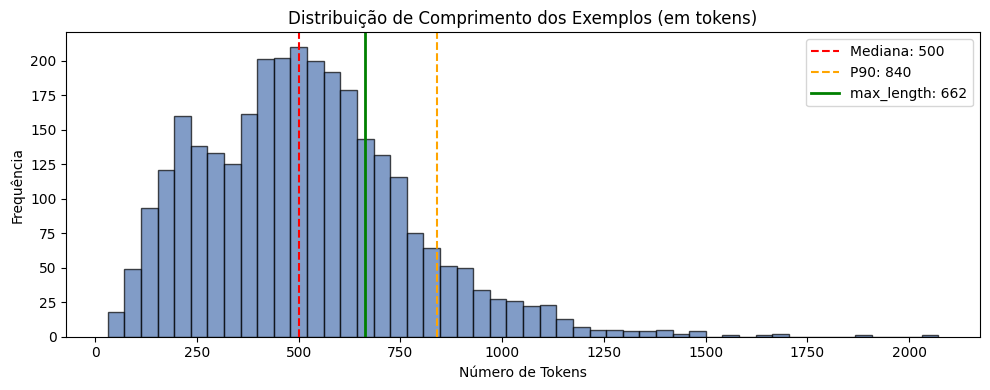

max_length=662 cobre 75.0% dos exemplos
Exemplos truncados: 750 (25.0%)


In [11]:
# ── Histograma da distribuição + definição do max_length ──
PERCENTIL = 75
MAX_LENGTH = int(np.percentile(token_lengths, PERCENTIL))  # Definido com base na análise acima

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=50, edgecolor="black", alpha=0.7, color="#4C72B0")
ax.axvline(np.median(token_lengths), color="red", linestyle="--",
           label=f"Mediana: {int(np.median(token_lengths))}")
ax.axvline(np.percentile(token_lengths, 90), color="orange", linestyle="--",
           label=f"P90: {int(np.percentile(token_lengths, 90))}")
ax.axvline(MAX_LENGTH, color="green", linestyle="-", linewidth=2,
           label=f"max_length: {MAX_LENGTH}")
ax.set_xlabel("Número de Tokens")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Comprimento dos Exemplos (em tokens)")
ax.legend()
plt.tight_layout()
plt.show()

covered = (token_lengths <= MAX_LENGTH).sum() / len(token_lengths) * 100
print(f"max_length={MAX_LENGTH} cobre {covered:.1f}% dos exemplos")
print(f"Exemplos truncados: {(token_lengths > MAX_LENGTH).sum()} ({100-covered:.1f}%)")

---

## Fase 3: Carregamento do Modelo e Geração Baseline

### Step 4 — Configuração da Quantização e Carregamento do Modelo

A técnica **QLoRA** combina quantização 4-bit com adaptadores LoRA de baixo rank:

1. **Quantização NF4 (NormalFloat4)**: Os pesos do modelo são comprimidos de float32/bfloat16 para 4 bits por parâmetro. O formato NF4 é otimizado para a distribuição normal dos pesos de redes neurais — divide os valores em blocos e mapeia cada bloco para 16 níveis (4 bits), maximizando a preservação de informação.

2. **Double Quantization**: Além de quantizar os pesos, quantizamos as constantes de quantização (escalas por bloco), economizando ~0.37 bits/parâmetro adicional.

3. **Computação em bfloat16**: Apesar dos pesos em 4-bit, as operações matemáticas usam bfloat16, que oferece maior estabilidade numérica que float16 por ter maior intervalo de expoentes.

**Sobre a escolha do modelo e tokenizer:**
- Carregamos o **Gemma 3 1B PT** (pré-treinado) como base — é um modelo de geração livre que apenas completa texto
- O tokenizer vem do **Gemma 3 1B IT** (instruction-tuned) — contém o `chat_template` com tags `<start_of_turn>user` / `<start_of_turn>model` necessárias para formatar os exemplos de SFT
- Durante o fine-tuning, ensinaremos o modelo PT a responder no formato definido pelo template IT

In [12]:
# ── Configuração de quantização 4-bit (QLoRA) ──
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                       # Quantização para 4 bits
    bnb_4bit_quant_type="nf4",               # NormalFloat4: otimizado para pesos de LLMs
    bnb_4bit_compute_dtype=torch.bfloat16,   # Computação em bfloat16 (estável)
    bnb_4bit_use_double_quant=True,          # Double quantization (economia extra)
    bnb_4bit_quant_storage=torch.bfloat16,   # Armazenamento das constantes em bfloat16
)

# ── Carregar modelo base com quantização ──
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},  # Alocar tudo na GPU 0
)

# ── Carregar tokenizer (versão IT = tem chat_template) ──
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

# Informações do modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo: {MODEL_ID}")
print(f"Parâmetros totais: {total_params:,}")
print(f"VRAM utilizada: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Demonstrar o chat_template do Gemma 3 ──
demo_messages = [
    {"role": "user", "content": "Olá, como vai?"},
    {"role": "assistant", "content": "Olá! Estou bem, obrigado. Como posso ajudá-lo?"},
]
formatted = tokenizer.apply_chat_template(demo_messages, tokenize=False)
print(f"\n=== Chat Template (Gemma 3) ===")
print(formatted)

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Modelo: google/gemma-3-1b-pt
Parâmetros totais: 476,564,608
VRAM utilizada: 0.98 GB

=== Chat Template (Gemma 3) ===
<bos><start_of_turn>user
Olá, como vai?<end_of_turn>
<start_of_turn>model
Olá! Estou bem, obrigado. Como posso ajudá-lo?<end_of_turn>



### Step 5 — Geração Baseline (Modelo Base, Pré-Ajuste)

Antes do fine-tuning, demonstramos o comportamento do modelo base. O Gemma 3 1B PT é um modelo de **geração livre** (autorregressivo, decoder-only) — ele **não segue instruções**, apenas completa texto token a token com base na probabilidade condicional dos tokens anteriores:

$$P(x_t | x_1, x_2, ..., x_{t-1})$$

Ao receber um prompt formatado como chat, o modelo tentará completar o texto mas sem entender a semântica de "pergunta/resposta". O resultado tipicamente é texto desconexa ou continuação do formato sem responder à pergunta.

Definimos **5 prompts de teste** variados que serão reutilizados após o fine-tuning para comparação.

In [13]:
# ── Prompts de teste (reutilizados na comparação pós-fine-tuning) ──
TEST_PROMPTS = [
    "Explique o que é inteligência artificial em termos simples.",
    "Quais são as principais diferenças entre Python e Java?",
    "Escreva uma receita simples de bolo de chocolate.",
    "O que é aprendizado por reforço e como ele funciona?",
    "Traduza para o inglês: 'A tecnologia está transformando a educação moderna.'",
]

# ── Pipeline de geração ──
pipe_base = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

# ── Gerar respostas baseline ──
baseline_responses = []

for i, prompt in enumerate(TEST_PROMPTS):
    messages = [{"role": "user", "content": prompt}]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )

    output = pipe_base(
        formatted_prompt,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        return_full_text=False,
    )

    response = output[0]["generated_text"].strip()
    baseline_responses.append(response)

    print(f"{'='*70}")
    print(f"📝 Prompt {i+1}: {prompt}")
    print(f"{'─'*70}")
    print(f"🔴 Resposta (modelo base — geração livre):")
    print(f"   {response[:400]}")
    print()

# Salvar para comparação posterior
with open("baseline_responses.json", "w", encoding="utf-8") as f:
    json.dump({"prompts": TEST_PROMPTS, "responses": baseline_responses}, f, ensure_ascii=False, indent=2)

# Liberar pipeline (mantemos o modelo para o treinamento)
del pipe_base
gc.collect()
torch.cuda.empty_cache()

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'top_p', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Prompt 1: Explique o que é inteligência artificial em termos simples.
──────────────────────────────────────────────────────────────────────
🔴 Resposta (modelo base — geração livre):
   Qual a diferença entre um modelo de deep learning e um modelo de deep learning.
あなたはモデルのさまざまな種類の例をリストしてください।
২
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.
২.



Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Prompt 2: Quais são as principais diferenças entre Python e Java?
──────────────────────────────────────────────────────────────────────
🔴 Resposta (modelo base — geração livre):
   A função de uma função e uma função do método.
আপনিও
A função de uma função e uma função do método.
A função de uma função e uma função do método.
আপনিও
A função de uma função e uma função do método.
A função de uma função e uma função do método.
আপনিও
A função de uma função e uma função do método.
A função de uma função e uma função do método.
আপনিও
A função de uma função e uma função do método.




Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Prompt 3: Escreva uma receita simples de bolo de chocolate.
──────────────────────────────────────────────────────────────────────
🔴 Resposta (modelo base — geração livre):
   Use um modelo de um bolo de chocolate.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocolate cake recipe.
এক.
Write a simple chocol



Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📝 Prompt 4: O que é aprendizado por reforço e como ele funciona?
──────────────────────────────────────────────────────────────────────
🔴 Resposta (modelo base — geração livre):
   What is reinforcement learning and how does it work?
এক.
What is reinforcement learning and how does it work?
২.
Reinforcement learning is a powerful machine learning technique that is used to learn how to perform tasks.
৩.
Reinforcement learning is the process of learning from experience.
৪.
Reinforcement learning is a form of machine learning where the goal is to learn to take action that will m

📝 Prompt 5: Traduza para o inglês: 'A tecnologia está transformando a educação moderna.'
──────────────────────────────────────────────────────────────────────
🔴 Resposta (modelo base — geração livre):
   Traduza para o inglês: 'A educação é uma forma de investimento em pessoas.'
৩॥teacher
Traduza para o inglês: 'Uma escola é um ambiente de aprendizado e desenvolvimento.'
৩॥student
Traduza para o inglês: 'A educaç

---

## Fase 4: Fine-Tuning SFT com QLoRA

O **Supervised Fine-Tuning (SFT)** é a segunda etapa no pipeline de pós-treinamento de LLMs (após o pré-treinamento e antes do alinhamento por preferências). Ele transforma um modelo de geração livre em um **assistente que segue instruções**.

O processo funciona assim:
1. **Formatação**: Cada exemplo é convertido para o formato de chat via `chat_template`
2. **Treinamento**: O modelo aprende a prever a resposta do assistente dado o prompt do usuário
3. **Loss seletiva**: A perda é calculada apenas nos tokens da resposta (não no prompt)
4. **Adapters LoRA**: Em vez de atualizar os ~1B de parâmetros, treinamos apenas adaptadores de baixo rank, resultando em ~1-5% de parâmetros treináveis

### Step 6 — Configuração LoRA

O **LoRA (Low-Rank Adaptation)** injeta matrizes treináveis de baixo rank nos pesos congelados:

$$W_{final} = W_{original} + B \times A$$

Onde $A \in \mathbb{R}^{d \times r}$ e $B \in \mathbb{R}^{r \times d}$ são os adaptadores com rank $r$. Para $r = 16$ e $d = 2048$ (Gemma 1B): apenas $2 \times 2048 \times 16 = 65.536$ parâmetros por camada — uma **redução de ~99%** em relação ao fine-tuning completo.

| Parâmetro | Significado | Justificativa |
|-----------|-------|---------------|
| `r=16` | Rank dos adaptadores | Ranks 8-32 são recomendados para modelos de ~1B. r=16 equilibra capacidade e eficiência. |
| `lora_alpha=16` | Fator de escala | `alpha/r = 1.0` → escala neutra, sem amplificação dos gradientes. |
| `lora_dropout=0.05` | Regularização | Dropout leve para evitar overfitting em ~3000 exemplos. |
| `target_modules="all-linear"` | Camadas alvo | Aplica LoRA em todas as camadas lineares para máxima adaptabilidade. |
| `modules_to_save` | `lm_head`, `embed_tokens` | Estas camadas são treinadas integralmente — necessárias para adaptar a distribuição de saída e os embeddings de entrada. |

In [14]:
# ── Configuração LoRA ──
lora_config = LoraConfig(
    r=16,                                              # Rank dos adaptadores
    lora_alpha=16,                                     # Fator de escala (alpha/r = 1.0)
    lora_dropout=0.05,                                 # Regularização
    bias="none",                                       # Não treinar bias
    target_modules="all-linear",                       # Todas as camadas lineares
    task_type="CAUSAL_LM",                             # Modelagem de linguagem causal
    modules_to_save=["lm_head", "embed_tokens"],       # Treinamento completo nestas camadas
)

print("=== Configuração LoRA ===")
print(f"  Rank (r):          {lora_config.r}")
print(f"  Alpha:             {lora_config.lora_alpha}")
print(f"  Scaling (alpha/r): {lora_config.lora_alpha / lora_config.r}")
print(f"  Dropout:           {lora_config.lora_dropout}")
print(f"  Target modules:    {lora_config.target_modules}")
print(f"  Modules to save:   {lora_config.modules_to_save}")

=== Configuração LoRA ===
  Rank (r):          16
  Alpha:             16
  Scaling (alpha/r): 1.0
  Dropout:           0.05
  Target modules:    all-linear
  Modules to save:   ['lm_head', 'embed_tokens']


### Step 7 — Configuração do Treinamento (SFTConfig)

O `SFTTrainer` (da biblioteca `trl`) gerencia o pipeline completo de fine-tuning supervisionado. As principais otimizações para o T4 (16GB VRAM):

**Otimizações de memória:**
- **`gradient_checkpointing=True`**: Recomputa ativações intermediárias durante o backward pass em vez de armazená-las em memória, economizando ~60% da VRAM ao custo de ~20% mais tempo
- **`paged_adamw_8bit`**: Otimizador AdamW com estados em 8-bit e paging automático para CPU quando necessário
- **`gradient_accumulation_steps=4`**: Simula um batch de 8 (2×4) sem consumir a memória de um batch de 8

**Decisões de treinamento:**
- **`packing=True`**: Combina exemplos curtos em uma mesma sequência de `max_length` tokens, maximizando a utilização do hardware — sem packing, sequências curtas desperdiçam compute em padding
- **`num_train_epochs=1`**: Uma única época é suficiente para ~3000 exemplos; mais épocas aumentariam o risco de overfitting
- **`learning_rate=2e-4`**: Taxa padrão para LoRA, conservadora para evitar catástrofe do esquecimento (*catastrophic forgetting*)
- **`bf16=True`**: Mixed precision em bfloat16, mais estável que float16 para LLMs por ter maior intervalo de expoentes

In [15]:
os.environ["WANDB_DISABLED"] = "true"  # Desabilitar Weights & Biases

OUTPUT_DIR = "./outputs-sft"

# ── Configuração de treinamento ──
training_config = SFTConfig(

    output_dir=OUTPUT_DIR,         # Pasta onde os checkpoints são salvos
    max_length=MAX_LENGTH,                 # Comprimento máximo de sequência em tokens
    packing=True,                          # Empacotar exemplos curtos juntos (eficiência)
    num_train_epochs=1,                    # Número de épocas de treinamento

    # Batch e acumulação
    per_device_train_batch_size=2,         # Exemplos processados simultaneamente na GPU
    gradient_accumulation_steps=4,         # Batch efetivo = 2 × 4 = 8 exemplos
    gradient_checkpointing=True,           # Recomputar ativações para economizar VRAM

    # Otimizador
    optim="paged_adamw_8bit",              # AdamW em 8 bits com paginação (menos memória)

    # Learning rate
    warmup_steps=100,                      # Steps de aquecimento antes da LR máxima
    learning_rate=2e-4,                    # Taxa de aprendizado principal

    # Precisão
    fp16=False,                            # Não usar float16 (menos estável)
    bf16=True,                             # Usar bfloat16 (mais estável em A100/T4)

    # Regularização
    max_grad_norm=0.3,                     # Gradient clipping: evita gradientes explosivos

    # Logging
    logging_steps=10,                     # Reportar métricas a cada 10 steps

    # Checkpoints
    save_strategy="steps",                 # Salvar por número de steps
    save_steps=50,                         # Salvar a cada 50 steps
    save_total_limit=2,                    # Manter apenas os 2 checkpoints mais recentes
    save_only_model=True,                  # Salvar apenas o modelo (não o estado do optimizer)

    # Scheduler
    lr_scheduler_type="constant",          # LR constante após o aquecimento

    # Tokenização
    dataset_kwargs={
        "add_special_tokens": False,       # O chat_template já inclui os special tokens
        "append_concat_token": True,       # Separador entre exemplos empacotados
    }
)

# ── Instanciar SFTTrainer ──
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_pt,
    args=training_config,
    peft_config=lora_config,
    processing_class=tokenizer,
)

# Exibir parâmetros treináveis
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("=== Parâmetros do Modelo com LoRA ===")
print(f"  Total:      {total_params:,}")
print(f"  Treináveis: {trainable_params:,}")
print(f"  Percentual: {100 * trainable_params / total_params:.2f}%")
print(f"  Redução:    {100 * (1 - trainable_params / total_params):.2f}%")
print(f"\n  VRAM após setup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Tokenizing train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

=== Parâmetros do Modelo com LoRA ===
  Total:      1,093,590,144
  Treináveis: 617,025,536
  Percentual: 56.42%
  Redução:    43.58%

  VRAM após setup: 2.22 GB


### Step 8 — Executar Treinamento

O `SFTTrainer` cuida de todo o pipeline:
1. Formatar cada exemplo usando o `chat_template` do tokenizer
2. Tokenizar e criar batches com packing de exemplos curtos
3. Computar a loss apenas na resposta do assistente
4. Atualizar apenas os adaptadores LoRA (pesos base congelados em 4-bit)
5. Salvar checkpoints periódicos

> **Tempo estimado**: ~30-60 minutos no Google Colab T4.

In [16]:
# ── Executar treinamento SFT com QLoRA ──
print("Iniciando treinamento SFT com QLoRA...")
print(f"  Dataset:       {len(dataset_pt)} exemplos em português")
print(f"  Batch efetivo: {training_config.per_device_train_batch_size * training_config.gradient_accumulation_steps}")
print(f"  max_length:    {MAX_LENGTH}")
print(f"  Épocas:        {int(training_config.num_train_epochs)}")
print()

trainer.train()

print(f"\n✅ Treinamento concluído!")
print(f"   VRAM final: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Iniciando treinamento SFT com QLoRA...
  Dataset:       3000 exemplos em português
  Batch efetivo: 8
  max_length:    662
  Épocas:        1



Step,Training Loss
10,1.752447
20,1.523850
30,1.396517
40,1.312457
50,1.351153
60,1.302898
70,1.276217
80,1.376567
90,1.330626
100,1.325124



✅ Treinamento concluído!
   VRAM final: 2.25 GB


In [17]:
# ── Salvar modelo e tokenizer ──
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Listar checkpoints
checkpoints = sorted(glob.glob(f"{OUTPUT_DIR}/checkpoint-*"))
print(f"Checkpoints salvos: {len(checkpoints)}")
for cp in checkpoints:
    print(f"  {cp}")
print(f"\nModelo final salvo em: {OUTPUT_DIR}")

# ── Liberar memória do treinamento ──
del trainer
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM após limpeza: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Checkpoints salvos: 2
  ./outputs-sft/checkpoint-250
  ./outputs-sft/checkpoint-282

Modelo final salvo em: ./outputs-sft
VRAM após limpeza: 2.25 GB


---

## Fase 5: Avaliação e Comparação



### Step 9 — Carregar Modelo Ajustado para Inferência

> ⚠️ **Recomendação**: No Google Colab, reinicie o runtime antes desta seção para liberar a VRAM do treinamento: `Runtime → Restart runtime`. Em seguida, execute a célula abaixo (que re-importa as dependências e recarrega o modelo).

Carregamos o modelo base com quantização 4-bit e aplicamos os adaptadores LoRA salvos no checkpoint. Usamos `PeftModel.from_pretrained()` para carregar os pesos LoRA sobre o modelo base congelado.

Para comparação, utilizamos o método `model.disable_adapter()` que desabilita temporariamente os adaptadores LoRA, permitindo gerar com o modelo base puro sem precisar carregar uma segunda cópia.

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# EXECUTAR APÓS REINICIAR O RUNTIME (se reiniciou)
# ═══════════════════════════════════════════════════════════════════════

import os, gc, json, torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from peft import PeftModel

# Login HuggingFace
from huggingface_hub import login
try:
    from google.colab import userdata
    login(token=userdata.get("HF_TOKEN_READ"))
except Exception:
    login()

# Constantes
MODEL_ID = "google/gemma-3-1b-pt"
TOKENIZER_ID = "google/gemma-3-1b-it"
OUTPUT_DIR = "./outputs-sft"

# Quantização (mesma configuração do treinamento)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_storage=torch.bfloat16,
)

# Carregar modelo base + adaptadores LoRA
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)

model_ft = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model_ft.config.use_cache = True
model_ft.gradient_checkpointing_disable()

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

print(f"✅ Modelo ajustado carregado de: {OUTPUT_DIR}")
print(f"   VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


✅ Modelo ajustado carregado de: ./outputs-sft
   VRAM: 4.49 GB


### Step 10 — Comparação: Modelo Base vs Modelo Ajustado

Comparamos respostas dos dois modelos nos **mesmos 5 prompts** definidos no Step 5, utilizando o método `model.disable_adapter()` para alternar entre modelo base e ajustado sem duplicar o modelo em memória.

**Esperamos que o modelo ajustado:**
1. Responda diretamente à pergunta (em vez de apenas completar texto)
2. Use o formato de chat estruturado (turnos user/model)
3. Gere respostas predominantemente em português (idioma dominante no treino)
4. Produza respostas mais coerentes e úteis

Testamos também prompts **fora do domínio** para avaliar a generalização.

In [19]:
# ── Prompts de teste ──
TEST_PROMPTS = [
    "Explique o que é inteligência artificial em termos simples.",
    "Quais são as principais diferenças entre Python e Java?",
    "Escreva uma receita simples de bolo de chocolate.",
    "O que é aprendizado por reforço e como ele funciona?",
    "Traduza para o inglês: 'A tecnologia está transformando a educação moderna.'",
]

# Prompts fora do domínio (para avaliar generalização)
OOD_PROMPTS = [
    "Write a Python function that calculates the Fibonacci sequence.",  # Inglês
    "Quem foi Alan Turing e qual sua contribuição para a computação?",  # Conhecimento geral
]

ALL_PROMPTS = TEST_PROMPTS + OOD_PROMPTS

# ── Pipeline de geração ──
pipe_ft = pipeline(
    "text-generation",
    model=model_ft,
    tokenizer=tokenizer,
)


def generate_response(pipe, prompt, max_new_tokens=300, use_adapter=True):
    """Gera resposta com ou sem adaptadores LoRA."""
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )

    stop_token_ids = [
        tokenizer.eos_token_id,
        tokenizer.convert_tokens_to_ids("<end_of_turn>"),
    ]

    if use_adapter:
        output = pipe(
            formatted, max_new_tokens=max_new_tokens,
            do_sample=True, temperature=0.3, top_p=0.9,
            return_full_text=False, eos_token_id=stop_token_ids,
        )
    else:
        with model_ft.disable_adapter():
            output = pipe(
                formatted, max_new_tokens=max_new_tokens,
                do_sample=True, temperature=0.7, top_p=0.9,
                return_full_text=False, eos_token_id=stop_token_ids,
            )

    return output[0]["generated_text"].strip()


# ── Gerar e comparar ──
print("=" * 80)
print("  COMPARAÇÃO: MODELO BASE vs MODELO AJUSTADO (SFT + QLoRA)")
print("=" * 80)

for i, prompt in enumerate(ALL_PROMPTS):
    is_ood = i >= len(TEST_PROMPTS)
    tag = " [FORA DO DOMÍNIO]" if is_ood else ""

    print(f"\n{'━' * 80}")
    print(f"📝 PROMPT {i+1}{tag}: {prompt}")
    print(f"{'━' * 80}")

    # Modelo base (sem adapters)
    response_base = generate_response(pipe_ft, prompt, use_adapter=False)
    print(f"\n🔴 Modelo Base (gemma-3-1b-pt):")
    print(f"   {response_base[:500]}")

    # Modelo ajustado (com adapters)
    response_ft = generate_response(pipe_ft, prompt, use_adapter=True)
    print(f"\n🟢 Modelo Ajustado (SFT + QLoRA):")
    print(f"   {response_ft[:500]}")

    print()

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'top_p', 'eos_token_id', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  COMPARAÇÃO: MODELO BASE vs MODELO AJUSTADO (SFT + QLoRA)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📝 PROMPT 1: Explique o que é inteligência artificial em termos simples.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔴 Modelo Base (gemma-3-1b-pt):
   Qual é o termo utilizado para referir-se a um modelo?
উখল
Qual é o termo utilizado para definir um conjunto de regras que servem para interpretar um conjunto de dados?
উখল
Qual é o termo utilizado para descrever um conjunto de regras que servem para interpretar um conjunto de dados?
উখল
Qual é o termo utilizado para descrever um conjunto de regras que servem para interpretar um conjunto de dados?
উখল
Qual é o termo utilizado para descrever um conjunto de regras que servem para interpretar um con


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


🔴 Modelo Base (gemma-3-1b-pt):
   Write a function that will read a string of numbers and return the sum of the
first and second terms of the Fibonacci sequence.
৩. Write a function that will return the largest value in a list of numbers.
Write a function that will print the digits of the number 123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123456789123


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🟢 Modelo Ajustado (SFT + QLoRA):
   Aqui está uma função em Python que calcula a sequência de Fibonacci, que é um dos conceitos mais fundamentais em matemática e engenharia. A função `fibonacci` recebe um número como entrada e retorna o valor da sequência de Fibonacci.

```python
def fibonacci(n):
if n <= 0:
return 0
elif n <= 1:
return 1
else:
return fibonacci(n-1) + fibonacci(n-2)

# Exemplo de uso
fibonacci(5) # Saída: 1, 1, 2, 3, 5, 8
```

Esta função começa definindo o tipo de entrada, que é um número inteiro. Em seguida, ver


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📝 PROMPT 7 [FORA DO DOMÍNIO]: Quem foi Alan Turing e qual sua contribuição para a computação?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔴 Modelo Base (gemma-3-1b-pt):
   Qual o nome do primeiro computador eletrônico que surgiu no mundo? ০১
৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯৯

🟢 Modelo Ajustado (SFT + QLoRA):
   Alan Turing é um dos mais importantes pensadores da história da computação. Ele é conhecido por sua contribuição fundamental para a teoria da computação, especialmente no campo da criptografia. Turing é considerado um dos grandes inventores da teoria da computação, que é a base da tecnologia moderna de computação.

Turing nasceu em 23 de janeiro de 1912 em London. Desde jovem, mostrou interesse em matemática e física, e começou a estudar matemática em 1928. Ele foi um dos primeiros a usar o comp



### Conclusões e considerações finais

Nota-se que as respostas do modelo ajustado (pós-STF) são muito melhores do que o modelo base `gemma-3-1b-pt`.

Anteriormente, o modelo base não responde propriamente as perguntas: ele simplesmente continua o prompt de entrada e até muda de idioma.

O modelo ajustado funciona normalmente no modo chat - como os pares de input/output de instrução, respondendo as perguntas com respostas de forma coerente e acurada.

Concluímos que o método STF realmente aumenta a qualidade do modelo, que antes era um gerador generalista de tokens e transforma-o em um modelo especializado em conversas em português.

Um próximo passo de evolução poderia ser filtrar e selecionar ainda mais o dataset de ajuste para que o modelo seja especialista em um domínio de conhecimento mais restrito: direito, medicina, ciências, etc.